In [1]:
# 调用render范例

In [ ]:
import os
from drone_renderer import DroneRenderer
from pytorch3d.renderer import look_at_view_transform
import matplotlib.pyplot as plt

# 1. 初始化渲染器
renderer = DroneRenderer(
    mesh_path="./data/sample/sample.obj",
    image_size=(480, 640),
    focal_length=500.0
)

# 2. 定义视角 (例如：距离 2.7m, 方位角 180 度)
R, T = look_at_view_transform(dist=2.7, elev=0, azim=180, device=renderer.device)

# 3. 渲染
rgb, depth = renderer.render(R, T)

# 4. 后处理深度图
clean_depth = renderer.clean_depth_map(depth)



## 梯度追踪示例
若要对相机参数（如位置 T 或旋转 R）进行优化，需要确保：
1. 输入的 `R` 和 `T` 是 `requires_grad=True` 的 Tensor。
2. 调用 `render` 方法时设置 `return_tensor=True`。

In [3]:
import torch

# 1. 准备可优化的参数
# 注意：这里我们需要克隆并设置 requires_grad，因为 look_at_view_transform 返回的可能不是叶子节点
R, T = look_at_view_transform(dist=2.7, elev=0, azim=180, device=renderer.device)
T_opt = T.clone().detach().requires_grad_(True)
R_opt = R.clone().detach().requires_grad_(True)

# 2. 渲染 (开启 return_tensor)
rgb_tensor, depth_tensor = renderer.render(R_opt, T_opt, return_tensor=True)

# 3. 计算 Loss
target_image = torch.zeros_like(rgb_tensor) # 假设目标是全黑
loss = torch.nn.functional.mse_loss(rgb_tensor, target_image)

# 4. 反向传播
loss.backward()

print(f"T gradients: {T_opt.grad}")
print(f"R gradients: {R_opt.grad}")

T gradients: tensor([[-0.0010, -0.1408,  0.0507]], device='cuda:0')
R gradients: tensor([[[-0.0271, -0.0141,  0.0198],
         [-0.0097, -0.1394,  0.0541],
         [-0.0650, -0.0233,  0.0295]]], device='cuda:0')


In [4]:
# 重新加载模块以应用更改
import importlib
import drone_renderer
importlib.reload(drone_renderer)
from drone_renderer import DroneRenderer

# 重新初始化渲染器
renderer = DroneRenderer(
    mesh_path="./data/sample/sample.obj",
    image_size=(480, 640),
    focal_length=500.0
)

--- 批量渲染测试 ---
Input R shape: torch.Size([2, 3, 3])
Input T shape: torch.Size([2, 3])
Output RGB shape: torch.Size([2, 480, 640, 3])
Output Depth shape: torch.Size([2, 480, 640])


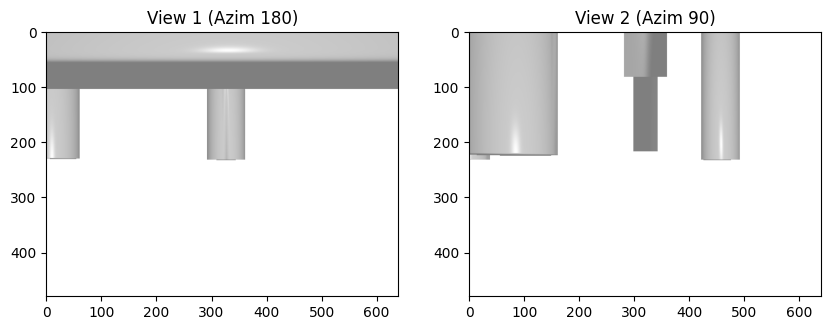

In [5]:
# ==========================================
# 批量渲染测试
# ==========================================
print("--- 批量渲染测试 ---")

# 构造 Batch 视角
# 视角 1: 正后方
R1, T1 = look_at_view_transform(dist=2.7, elev=0, azim=180, device=renderer.device)
# 视角 2: 左侧方
R2, T2 = look_at_view_transform(dist=2.7, elev=0, azim=90, device=renderer.device)

# 拼接 Batch (N=2)
R_batch = torch.cat([R1, R2], dim=0) # [2, 3, 3]
T_batch = torch.cat([T1, T2], dim=0) # [2, 3]

print(f"Input R shape: {R_batch.shape}")
print(f"Input T shape: {T_batch.shape}")

# 渲染
rgb_batch, depth_batch = renderer.render(R_batch, T_batch)

print(f"Output RGB shape: {rgb_batch.shape}")     # 期望: [2, 480, 640, 3]
print(f"Output Depth shape: {depth_batch.shape}") # 期望: [2, 480, 640]

# 可视化
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(rgb_batch[0].cpu().numpy())
plt.title("View 1 (Azim 180)")
plt.subplot(1, 2, 2)
plt.imshow(rgb_batch[1].cpu().numpy())
plt.title("View 2 (Azim 90)")
plt.show()